# Merging GeoTIFF Tiles

``merge_tifs`` stitches a folder of GeoTIFF tiles into a single raster. The sample data in ``data/quartered_binary_tifs/`` contains four quarters of ``g2_26729_linear_categories.tif`` plus a fifth tile covering the same extent as the top-left quarter but with only binary categories, and named with an older date to demo the ``dedup`` functionality.

In [1]:
import rioxarray as rxr
import matplotlib.pyplot as plt

from shelterbelts.classifications.merge_tifs import merge_tifs
from shelterbelts.utils.filepaths import quartered_tifs_dir, _repo_root
from shelterbelts.utils.visualisation import visualise_categories
from shelterbelts.indices.shelter_categories import shelter_categories_cmap, shelter_categories_labels

In [2]:
# Listing the files to merge
!ls {_repo_root / 'data' / 'quartered_linear_tifs'}/*.tif

/home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/2019_g2_26729_TL_binary.tif
/home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/2020_g2_26729_TL.tif
/home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/g2_26729_BL.tif
/home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/g2_26729_BR.tif
/home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/g2_26729_TR.tif


## Merging four tiles (no deduplication)

In this first example, the top left quarter happens to use the '2019' (binary) tif over the '2020' categorical tif that we actually want.

In [3]:
da = merge_tifs(quartered_tifs_dir, suffix='.tif', dont_reproject=True)

Merging with crs: EPSG:32755
Working on 0/5: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/g2_26729_TR.tif
Saved: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/data_quartered_linear_tifs_footprints.gpkg
Working on 0/5: g2_26729_TR.tif
Merging 5 tiles
Saved: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs_merged.tif


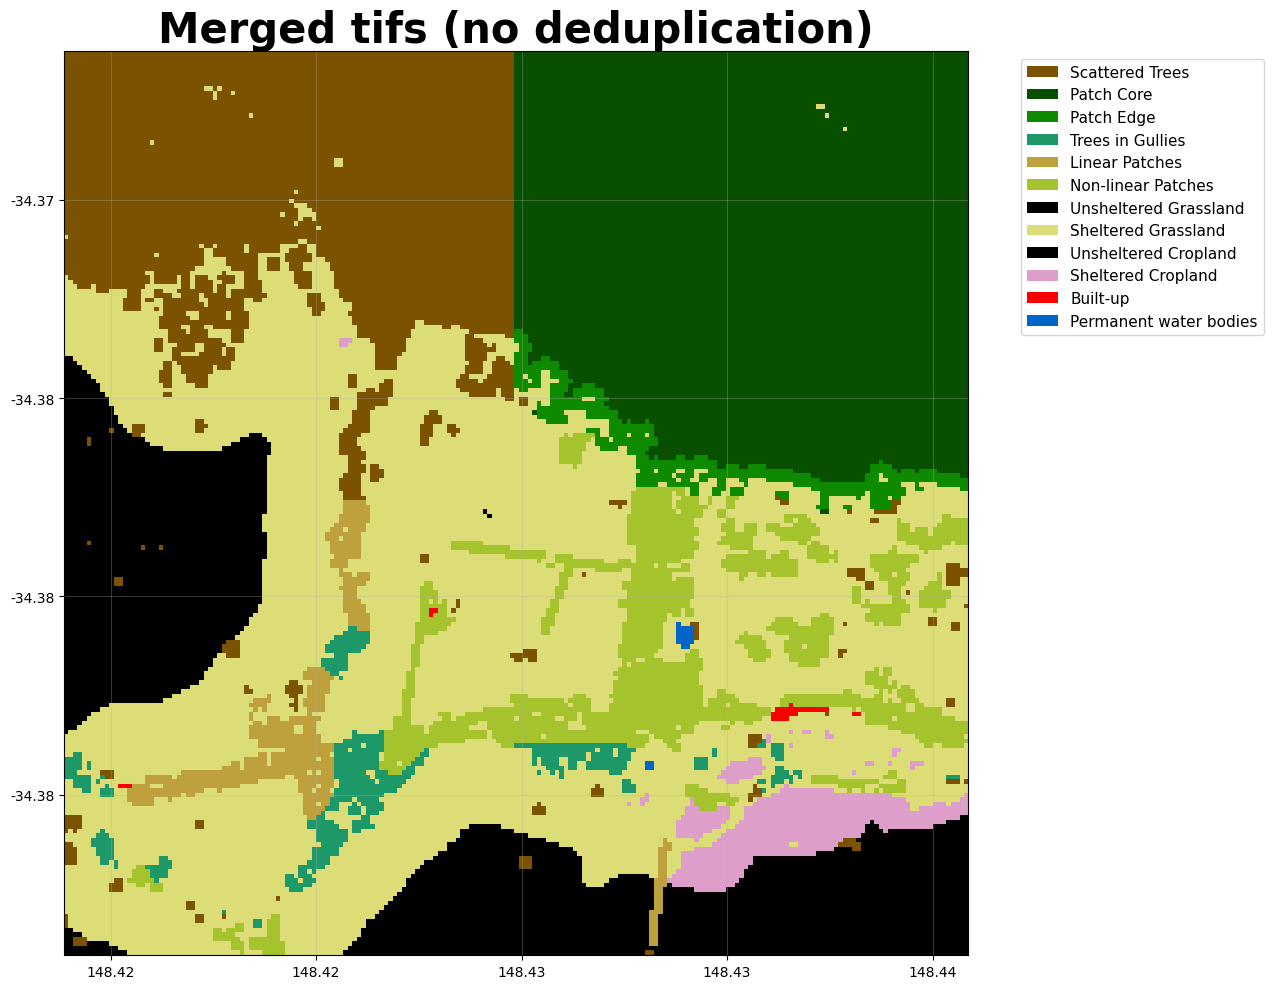

In [4]:
visualise_categories(da, colormap=shelter_categories_cmap, labels=shelter_categories_labels,
                     title='Merged tifs (no deduplication)')

## Merging with deduplication

In this second example, we use ``dedup=True`` to choose the most recent tile when multiple tiles overlap (this is relevant when downloading from ELVIS and you want the most recent lidar aquisition)

In [5]:
da_dedup = merge_tifs(quartered_tifs_dir, tmpdir='tmpdir', suffix='.tif',
                      dont_reproject=True, dedup=True)

Merging with crs: EPSG:32755
Working on 0/5: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/g2_26729_TR.tif
Saved: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/data_quartered_linear_tifs_footprints.gpkg
Saved: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs/footprints_unique.gpkg
Working on 0/4: g2_26729_TR.tif
Merging 4 tiles
Saved: /home/christopher-bradley/repos/shelterbelts/data/quartered_linear_tifs_merged.tif


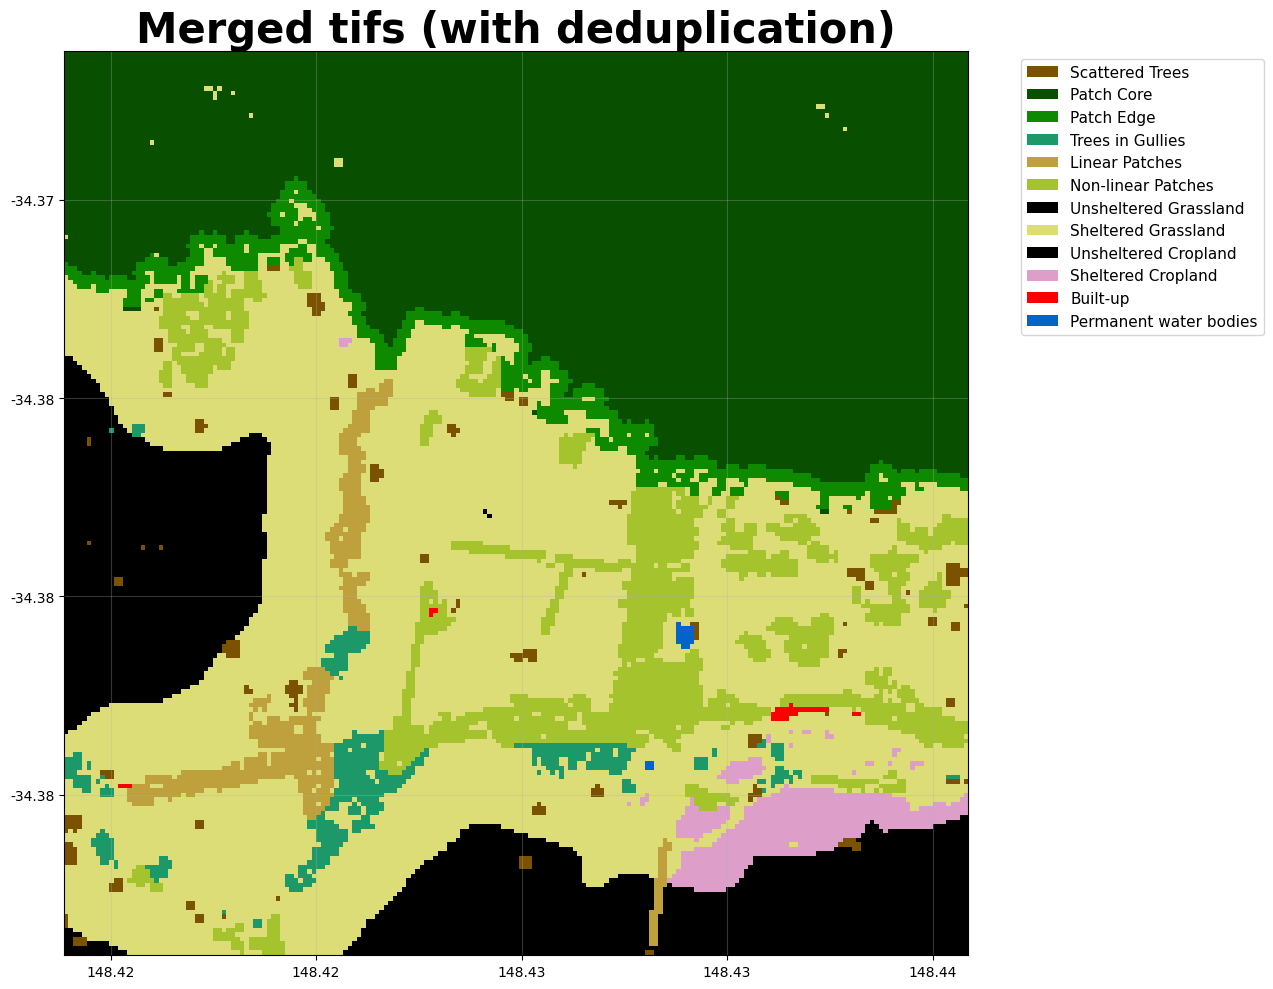

In [6]:
visualise_categories(da_dedup, colormap=shelter_categories_cmap, labels=shelter_categories_labels,
                     title='Merged tifs (with deduplication)')